<a href="https://colab.research.google.com/github/TamurOne10/Campus_Placement_Analysis-and-ML-model-/blob/main/webscraping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import yfinance as yf

# Download Tesla stock data (TSLA)
tesla_stock = yf.download('TSLA', start='2010-01-01', end='2023-01-01')
tesla_stock.reset_index(inplace=True)
tesla_stock.head()


/tmp/ipython-input-1-4033413300.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tesla_stock = yf.download('TSLA', start='2010-01-01', end='2023-01-01')
[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
Ticker,,TSLA,TSLA,TSLA,TSLA,TSLA
0,2010-06-29,1.592667,1.666667,1.169333,1.266667,281494500
1,2010-06-30,1.588667,2.028000,1.553333,1.719333,257806500
2,2010-07-01,1.464000,1.728000,1.351333,1.666667,123282000
3,2010-07-02,1.280000,1.540000,1.247333,1.533333,77097000
4,2010-07-06,1.074000,1.333333,1.055333,1.333333,103003500


In [ ]:
tesla_stock.tail(5)

Price,Date,Close,High,Low,Open,Volume
Ticker,,TSLA,TSLA,TSLA,TSLA,TSLA
3145,2022-12-23,123.150002,128.619995,121.019997,126.370003,166989700
3146,2022-12-27,109.099998,119.669998,108.760002,117.500000,208643400
3147,2022-12-28,112.709999,116.269997,108.239998,110.349998,221070500
3148,2022-12-29,121.820000,123.570000,117.500000,120.389999,221923300
3149,2022-12-30,123.180000,124.480003,119.750000,119.949997,157777300


In [ ]:
# Download GameStop stock data (GME)
gme_stock = yf.download('GME', start='2010-01-01', end='2023-01-01')
gme_stock.reset_index(inplace=True)
gme_stock.head()


/tmp/ipython-input-3-531153281.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gme_stock = yf.download('GME', start='2010-01-01', end='2023-01-01')
[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
Ticker,,GME,GME,GME,GME,GME
0,2010-01-04,3.854643,3.863059,3.703150,3.714933,26702800
1,2010-01-05,3.959005,3.996037,3.854644,3.856327,21269600
2,2010-01-06,4.044852,4.056634,3.908508,3.948906,21471200
3,2010-01-07,3.443929,3.563440,3.268871,3.368183,164761200
4,2010-01-08,3.415315,3.573540,3.405215,3.474228,47872400


In [10]:
import requests
import pandas as pd

def get_tesla_revenue_api():
    API_KEY = 'YOUR_API_KEY'  # Get free API key from Alpha Vantage
    url = f"https://www.alphavantage.co/query?function=INCOME_STATEMENT&symbol=TSLA&apikey={API_KEY}"

    try:
        response = requests.get(url)
        data = response.json()

        if 'quarterlyReports' in data:
            revenue_data = []
            for report in data['quarterlyReports'][:4]:  # Last 4 quarters
                revenue_data.append({
                    'Date': report['fiscalDateEnding'],
                    'Revenue': report['totalRevenue']
                })

            df = pd.DataFrame(revenue_data)
            return df
        else:
            print("Error in API response:", data.get('Note', 'Unknown error'))
            return None

    except Exception as e:
        print(f"Error: {e}")
        return None

# Get revenue data via API
tesla_revenue_api = get_tesla_revenue_api()
if tesla_revenue_api is not None:
    print(tesla_revenue_api)

         Date      Revenue
0  2025-03-31  19335000000
1  2024-12-31  25707000000
2  2024-09-30  25182000000
3  2024-06-30  25500000000


NameError: name 'gme_revenue' is not defined

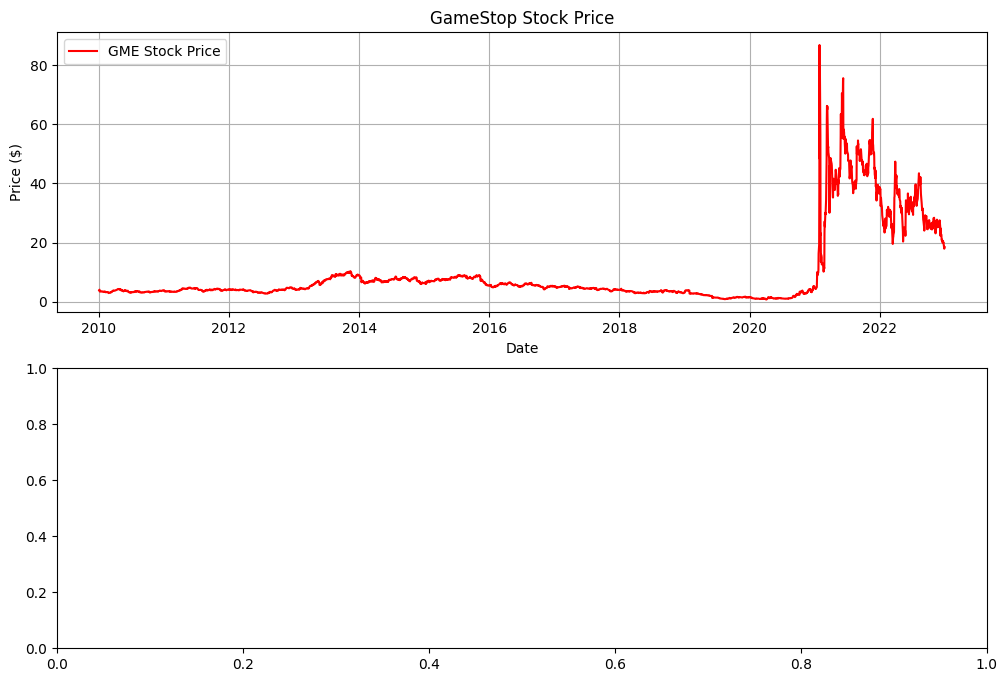

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(12, 8))

# GameStop stock closing price plot
axs[0].plot(gme_stock['Date'], gme_stock['Close'], label='GME Stock Price', color='red')
axs[0].set_title('GameStop Stock Price')
axs[0].set_xlabel('Date')
axs[0].set_ylabel('Price ($)')
axs[0].legend()
axs[0].grid(True)

# GameStop revenue plot
axs[1].bar(gme_revenue['Date'], gme_revenue['Revenue'], label='GME Revenue', color='orange')
axs[1].set_title('GameStop Revenue')
axs[1].set_xlabel('Date')
axs[1].set_ylabel('Revenue ($ Billion)')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()


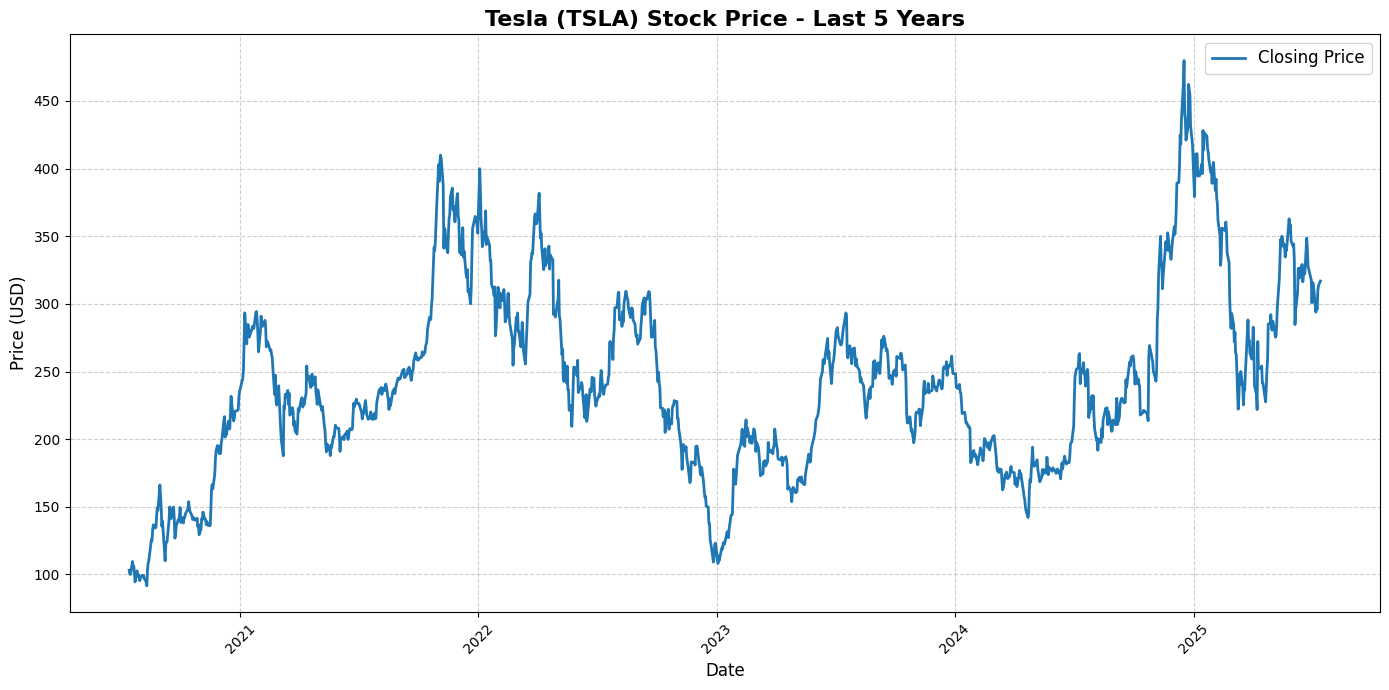

In [11]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd

def fetch_tesla_stock_data():
    """Fetch Tesla's historical stock data"""
    tesla = yf.Ticker("TSLA")
    hist = tesla.history(period="5y")  # Get 5 years of data
    return hist

def make_graph(data, title, x_label='Date', y_label='Price (USD)'):
    """Create a graph of stock data"""
    plt.figure(figsize=(14, 7))

    # Plot closing price
    plt.plot(data.index, data['Close'], label='Closing Price', linewidth=2)

    # Customize the graph
    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel(x_label, fontsize=12)
    plt.ylabel(y_label, fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=12)

    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45)

    # Show the graph
    plt.tight_layout()
    plt.show()

# Fetch Tesla stock data
tesla_data = fetch_tesla_stock_data()

# Create graph with a title
graph_title = "Tesla (TSLA) Stock Price - Last 5 Years"
make_graph(tesla_data, title=graph_title)

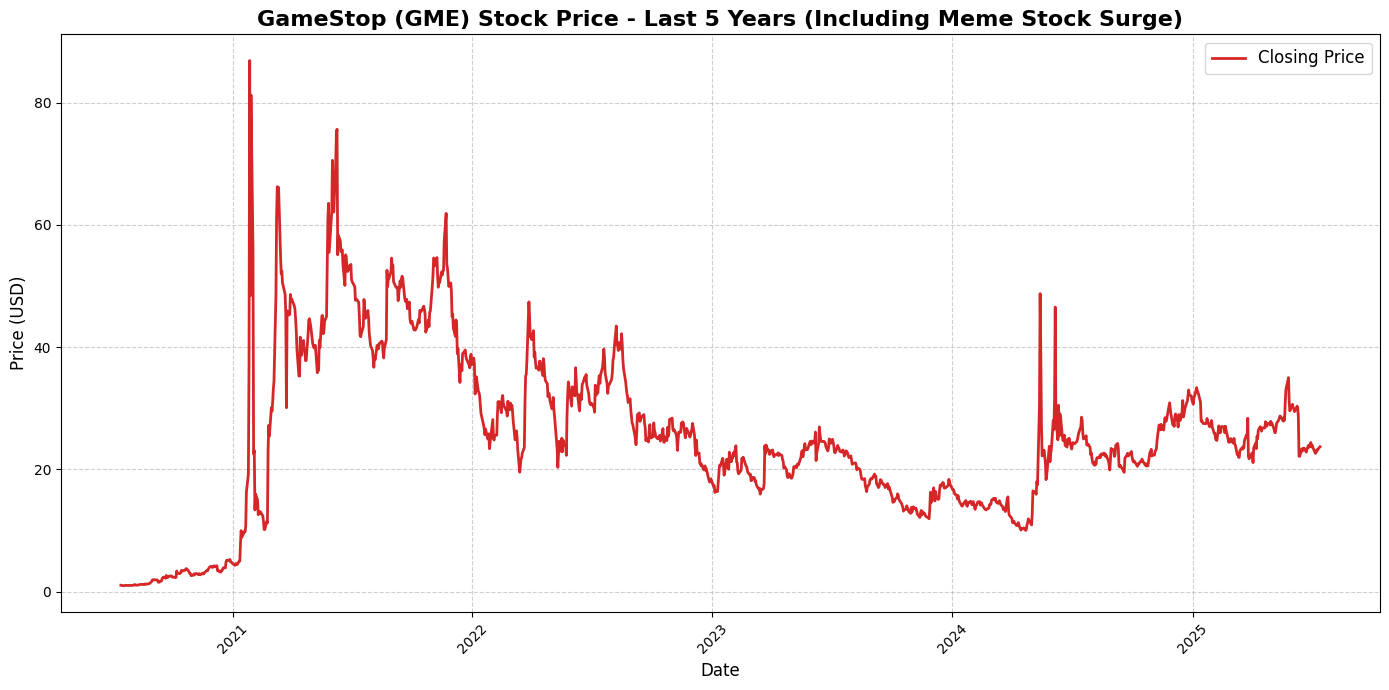

In [12]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd

def fetch_gamestop_stock_data():
    """Fetch GameStop's historical stock data"""
    gme = yf.Ticker("GME")
    hist = gme.history(period="5y")  # Get 5 years of data to capture the meme stock phenomenon
    return hist

def make_graph(data, title, x_label='Date', y_label='Price (USD)'):
    """Create a graph of stock data"""
    plt.figure(figsize=(14, 7))

    # Plot closing price
    plt.plot(data.index, data['Close'], label='Closing Price', linewidth=2, color='#d62728')  # Using red color for GME

    # Customize the graph
    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel(x_label, fontsize=12)
    plt.ylabel(y_label, fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=12)

    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45)

    # Show the graph
    plt.tight_layout()
    plt.show()

# Fetch GameStop stock data
gme_data = fetch_gamestop_stock_data()

# Create graph with a title
graph_title = "GameStop (GME) Stock Price - Last 5 Years (Including Meme Stock Surge)"
make_graph(gme_data, title=graph_title)